In [67]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np


In [68]:
trainset = pd.read_csv("../trainset.csv")

In [69]:
trainset.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [70]:
print(trainset.shape)

(1919, 69)


In [71]:
trainset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [72]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset.columns]

trainset[var_numericas] = trainset[var_numericas].astype('float64')
trainset[var_categoricas] = trainset[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 0
[]
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl', 'volumen_corpuscular_medio', 'conc_hemoglobina_media', 'ancho_distribucion_eritrocitos', 'plaquetas_totales', 'volumen_plaquetario_medio', 'trigliceridos_mmol_l', 'ldl_martin_mmol_l', 'hdl_mmol_l', 'plomo_sangre_umol_l', 'cadmio_sangre_nmol_l', 'mercurio_sangre_nmol_l', 'selenio_sangre_umol_l', 

Separamos solo las variables numericas, para k-means.

In [74]:
X_train = trainset.select_dtypes(include=['number'])
X_train.shape

(1919, 69)

## Clustering con K-MEANS

In [8]:
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    silhouette_scores[k] = score
    print(f"Para K={k}, el Silhouette Score es: {score:.4f}")

Para K=2, el Silhouette Score es: 0.0890
Para K=3, el Silhouette Score es: 0.0512
Para K=4, el Silhouette Score es: 0.0467
Para K=5, el Silhouette Score es: 0.0333


In [9]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nEl K óptimo según el Silhouette Score es: K={best_k} (Score: {silhouette_scores[best_k]:.4f})")


El K óptimo según el Silhouette Score es: K=2 (Score: 0.0890)


## USANDO K-PROTOTYPES

In [10]:
var_categoricas = [
    'genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1',
    'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1',
    'convulsiones_1', 'caidas_1', 'fracturas_1', 'medicacion_osteoporosis_1',
    'aprueba_cond4_1', 'tamano_manguito_pa_3.0', 'tamano_manguito_pa_4.0',
    'tamano_manguito_pa_5.0', 'estado_elastografia_1', "tipo_sonda_elasto_b'M'",
    "tipo_sonda_elasto_b'XL'", 'raza_etnia_2.0', 'raza_etnia_3.0',
    'raza_etnia_4.0', 'raza_etnia_6.0', 'raza_etnia_7.0'
]

In [11]:
cat_indices = [trainset.columns.get_loc(col) for col in var_categoricas]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Columnas categóricas: 23


In [12]:
matriz_datos = trainset.to_numpy()

In [13]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset)

Calculando la matriz de Distancia de Gower...


In [14]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)

    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')

    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")

    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:
Para K=2 -> Silhouette Score (Gower): 0.1016
Para K=3 -> Silhouette Score (Gower): 0.0887
Para K=4 -> Silhouette Score (Gower): 0.0693
Para K=5 -> Silhouette Score (Gower): 0.0656
----------------------------------------
El conjunto óptimo es K = 2 con un Silhouette Score de 0.1016


Se han modificado los datasets para eliminar el proceso del OHE de cara a probar el metodo k-prototypes ya que si no estemetodo puede por ejemplo interpretar que hay 5 variables distintas de raza. Esto multiplicará por 5 la importancia matemática de la raza a la hora de agrupar pacientes.

In [15]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [16]:
trainset_no_ohe.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0


In [17]:
trainset_no_ohe.shape

(1919, 62)

In [18]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas_no_ohe] = trainset_no_ohe[var_numericas_no_ohe].astype('float64')
trainset_no_ohe[var_categoricas_no_ohe] = trainset_no_ohe[var_categoricas_no_ohe].astype('object')


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [19]:
cat_indices = [trainset_no_ohe.columns.get_loc(col) for col in var_categoricas_no_ohe]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Columnas categóricas: 16


In [20]:
matriz_datos = trainset_no_ohe.to_numpy()

In [21]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [22]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)

    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')

    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")

    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:
Para K=2 -> Silhouette Score (Gower): 0.0865
Para K=3 -> Silhouette Score (Gower): 0.0853
Para K=4 -> Silhouette Score (Gower): 0.0850
Para K=5 -> Silhouette Score (Gower): 0.0627
----------------------------------------
El conjunto óptimo es K = 2 con un Silhouette Score de 0.0865


OBSERVACIONES:

Se puede apreciar que al usar ambos metodos se obtienen unas metricas muy similares y muy pobres.

Esto puede deberse a que el numero de columnas es muy grande y el espacio geométrico se vuelve tan masivo que la distancia matemática entre cualquier par de pacientes se vuelve casi igual y por tanto el algoritmo no detecta densidades claras.

In [23]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


## Uso de PCA para reducción de dimensionalidad en el datsaset

Para este apartado se utiliza el dataset previo al OHE ya que los metodos de clustering con variables categoricas requieren qeu la variable sea la original.

In [24]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np


In [25]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [26]:
trainset_no_ohe.shape

(1919, 62)

In [27]:
trainset_no_ohe.head(20)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,1,0,0,0,0,1,3.0,1,b'M',7.0
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,1,0,0,0,0,1,3.0,1,b'M',3.0
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,1,0,0,0,0,0,3.0,1,b'M',3.0


In [28]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas_no_ohe] = trainset_no_ohe[var_numericas_no_ohe].astype('float64')
trainset_no_ohe[var_categoricas_no_ohe] = trainset_no_ohe[var_categoricas_no_ohe].astype('object')


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

### FAMD (Factor Analysis of Mixed Data):

Internamente aplica PCA a los números, MCA a las categorías, y equilibra ambos resultados para crear nuevas variables continuas que resumen todo.

In [29]:
import matplotlib.pyplot as plt
import prince

famd_completo = prince.FAMD(n_components=trainset_no_ohe.shape[1], random_state=42)
famd_completo.fit(trainset_no_ohe)

FAMD(n_components=62, random_state=42)

In [30]:
# 2. Calculamos la varianza explicada por cada componente y la acumulada
# Prince almacena el ratio de varianza en el atributo explained_inertia_
varianza_individual = np.array(famd_completo.percentage_of_variance_)

# (Opcional/Seguridad): Algunas versiones de Prince devuelven porcentajes (0-100)
# en lugar de ratios (0-1). Si ese es el caso, lo normalizamos:
if varianza_individual.sum() > 1.5:
    varianza_individual = varianza_individual / 100

varianza_acumulada = np.cumsum(varianza_individual)

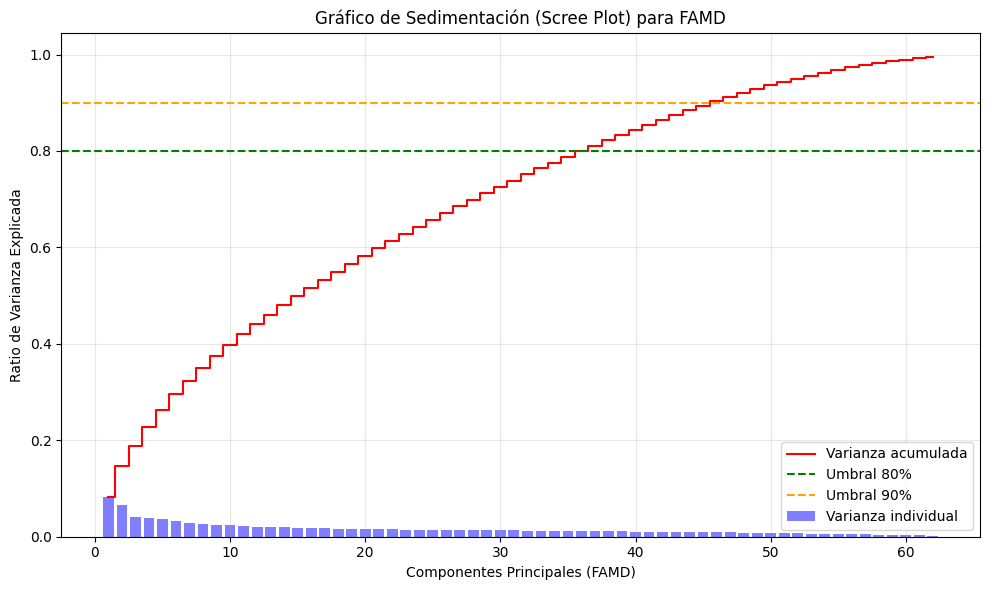

In [31]:
# 3. Graficamos
plt.figure(figsize=(10, 6))

# Gráfico de barras para la varianza de cada componente individual
plt.bar(range(1, len(varianza_individual) + 1), varianza_individual, alpha=0.5, align='center',
        label='Varianza individual', color='blue')

# Gráfico de línea para la varianza acumulada
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid',
         label='Varianza acumulada', color='red')

# Añadimos líneas de referencia (ej. 80% y 90% de la información)
plt.axhline(y=0.80, color='g', linestyle='--', label='Umbral 80%')
plt.axhline(y=0.90, color='orange', linestyle='--', label='Umbral 90%')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales (FAMD)')
plt.title('Gráfico de Sedimentación (Scree Plot) para FAMD')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Iniciando evaluación exhaustiva (FAMD + KMeans)...

[ Entrenando FAMD con 3 variables ]
Info retenida: 18.8%
  -> Para K=2 | Silhouette Score: 0.2796
  -> Para K=3 | Silhouette Score: 0.3024
  -> Para K=4 | Silhouette Score: 0.2664
  -> Para K=5 | Silhouette Score: 0.2646

[ Entrenando FAMD con 5 variables ]
Info retenida: 26.2%
  -> Para K=2 | Silhouette Score: 0.2189
  -> Para K=3 | Silhouette Score: 0.2194
  -> Para K=4 | Silhouette Score: 0.1968
  -> Para K=5 | Silhouette Score: 0.1895

[ Entrenando FAMD con 7 variables ]
Info retenida: 32.1%
  -> Para K=2 | Silhouette Score: 0.1907
  -> Para K=3 | Silhouette Score: 0.1786
  -> Para K=4 | Silhouette Score: 0.1634
  -> Para K=5 | Silhouette Score: 0.1692

[ Entrenando FAMD con 10 variables ]
Info retenida: 39.7%
  -> Para K=2 | Silhouette Score: 0.1382
  -> Para K=3 | Silhouette Score: 0.1436
  -> Para K=4 | Silhouette Score: 0.1318
  -> Para K=5 | Silhouette Score: 0.1183

[ Entrenando FAMD con 12 variables ]
Info retenida: 43.7%
 

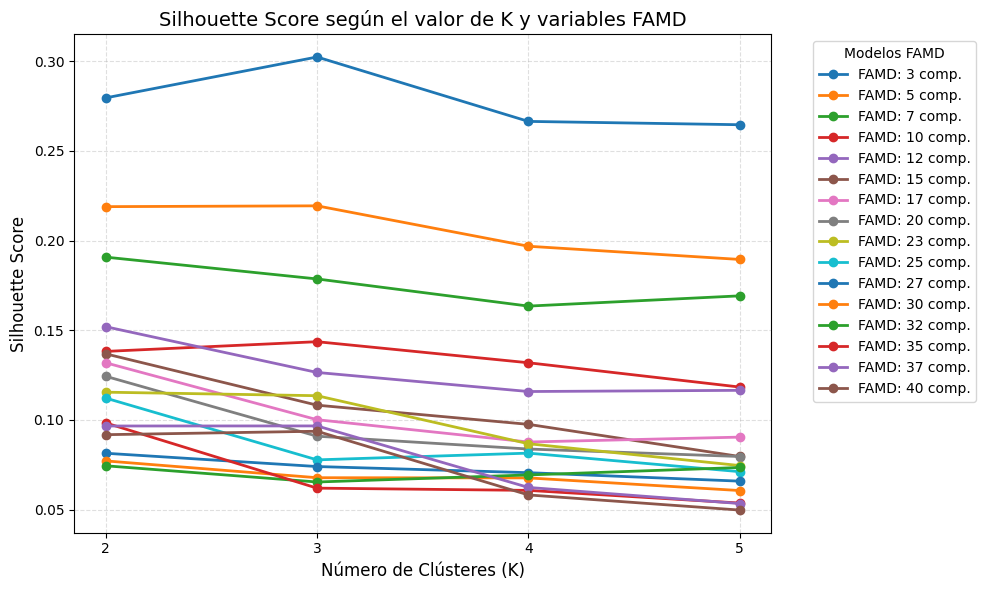

In [32]:
componentes_a_probar = [3, 5, 7, 10, 12, 15, 17, 20, 23, 25, 27, 30, 32, 35, 37, 40]

rango_k = range(2, 6) # K desde 2 hasta 6 (el 7 no se incluye)

# Diccionario para guardar los resultados y graficarlos luego
resultados_grid = {}

print("Iniciando evaluación exhaustiva (FAMD + KMeans)...")
print("=" * 60)

# Bucle externo: Iteramos sobre el número de componentes FAMD
for n_famd in componentes_a_probar:
    print(f"\n[ Entrenando FAMD con {n_famd} variables ]")

    # 1. Aplicar FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_reducido = famd_temp.fit_transform(trainset_no_ohe)

    # 2. Extraer la información retenida (manejo de versiones de prince)
    try:
        varianza_array = np.array(famd_temp.percentage_of_variance_)
        varianza_retenida = varianza_array.sum()
        if varianza_retenida <= 1.5:
            varianza_retenida *= 100
    except AttributeError:
        varianza_retenida = sum(famd_temp.explained_inertia_) * 100

    print(f"Info retenida: {varianza_retenida:.1f}%")

    # Lista para guardar los scores de este modelo FAMD
    scores_k = []

    # Bucle interno: Iteramos sobre el número de clústeres (K)
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_reducido)

        score = silhouette_score(X_reducido, labels)
        scores_k.append(score)

        print(f"  -> Para K={k} | Silhouette Score: {score:.4f}")

    # Guardamos los resultados en el diccionario
    resultados_grid[n_famd] = scores_k

print("\n" + "=" * 60)
print("Generando gráfico de resultados...")

# 3. Graficar los resultados
plt.figure(figsize=(10, 6))

# Dibujar una línea por cada valor de componentes FAMD probado
for n_famd, scores in resultados_grid.items():
    plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Silhouette Score según el valor de K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k)) # Asegurar que el eje X muestre solo enteros (2, 3, 4, 5, 6)

# Poner la leyenda fuera del gráfico para que no tape las líneas
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## K-Medioids (CLARA)

CLARA es simplemente el algoritmo PAM ejecutado sobre múltiples muestras aleatorias

In [33]:
import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np
import pandas as pd

from itertools import combinations
import heapq

In [34]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [35]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas] = trainset_no_ohe[var_numericas].astype('float64')
trainset_no_ohe[var_categoricas] = trainset_no_ohe[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [36]:
trainset_no_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [37]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [38]:
resultados_pam = {}
mejor_k_pam = -1
mejor_score_pam = -1

for k in range(2, 6):
    # Usamos el algoritmo PAM clásico
    km = kmedoids.KMedoids(n_clusters=k, method='pam', random_state=42)
    c = km.fit(matriz_distancias_gower)
    labels_pam = c.labels_

    score_pam = silhouette_score(matriz_distancias_gower, labels_pam, metric='precomputed')
    resultados_pam[k] = score_pam
    print(f"PAM -> Para K={k} | Silhouette Score (Gower): {score_pam:.4f}")

    if score_pam > mejor_score_pam:
        mejor_score_pam = score_pam
        mejor_k_pam = k

print(f"🏆 Mejor K para PAM: {mejor_k_pam} (Score: {mejor_score_pam:.4f})")

print("\n" + "="*60)
print("2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO")
print("="*60)

PAM -> Para K=2 | Silhouette Score (Gower): 0.0954
PAM -> Para K=3 | Silhouette Score (Gower): 0.0861
PAM -> Para K=4 | Silhouette Score (Gower): 0.0785
PAM -> Para K=5 | Silhouette Score (Gower): 0.0675
🏆 Mejor K para PAM: 2 (Score: 0.0954)

2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO


### Aplicando reducción de dimensionalidad FAMD


1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3448
  -> K=3 | Silhouette: 0.3973
  -> K=4 | Silhouette: 0.3131
  -> K=5 | Silhouette: 0.3328

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2662
  -> K=3 | Silhouette: 0.2964
  -> K=4 | Silhouette: 0.2675
  -> K=5 | Silhouette: 0.2577

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2219
  -> K=3 | Silhouette: 0.2359
  -> K=4 | Silhouette: 0.2191
  -> K=5 | Silhouette: 0.2103

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1902
  -> K=3 | Silhouette: 0.1923
  -> K=4 | Silhouette: 0.1850
  -> K=5 | Silhouette: 0.1722

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.1709
  -> K=3 | Silhouette: 0.1759
  -> K=4 | Silhouette: 0.1396
  -> K=5 | Silhouette: 0.1471

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1663
  -> K=3 | Silhouette: 0.1588
  -> K=4 | Silhouette: 0.1470
  -> K=5 | Silhou

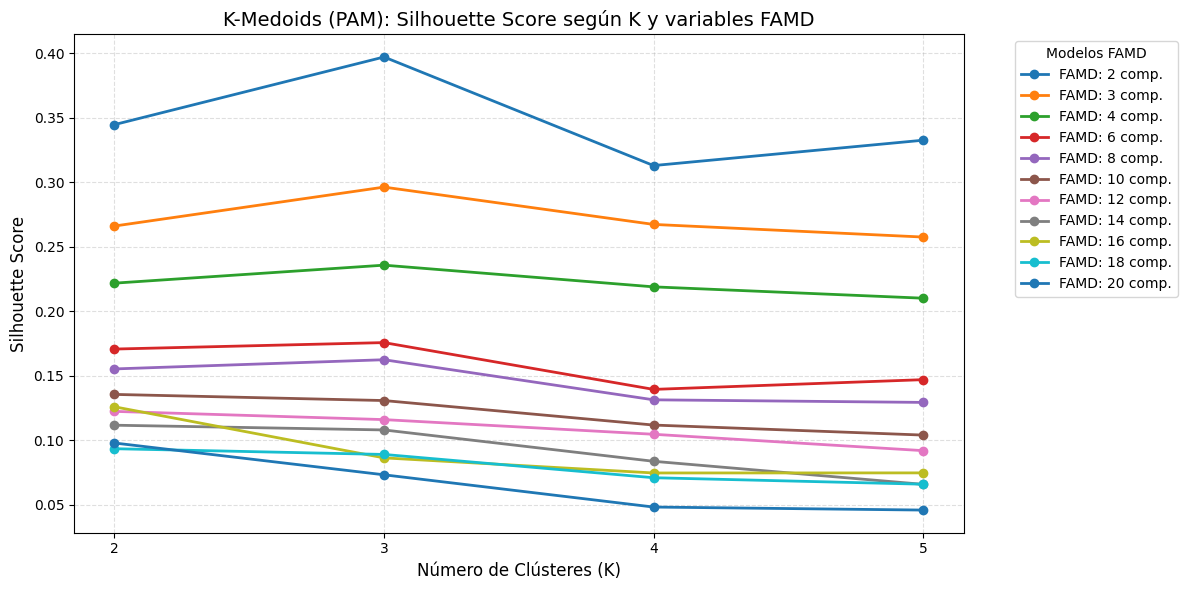

In [39]:
print("\n" + "="*60)
print("1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados y graficarlos
resultados_silhouette_pam = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_pam = -1
mejor_k_global_pam = -1
mejor_famd_global_pam = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")

    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()

    scores_sil_k = []

    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Al usar matriz_famd (coordenadas continuas), PAM usará distancia Euclidiana internamente
        km = kmedoids.KMedoids(n_clusters=k, method='pam', metric='euclidean', random_state=42)
        c = km.fit(matriz_famd)
        labels_pam = c.labels_

        # OJO: Calculamos el Silhouette sobre la matriz continua de FAMD, ya NO usamos Gower
        score_pam = silhouette_score(matriz_famd, labels_pam, metric='euclidean')
        scores_sil_k.append(score_pam)

        print(f"  -> K={k} | Silhouette: {score_pam:.4f}")

        # Actualizar el campeón absoluto
        if score_pam > mejor_score_global_pam:
            mejor_score_global_pam = score_pam
            mejor_k_global_pam = k
            mejor_famd_global_pam = n_famd

    # Guardar en diccionario para la gráfica
    resultados_silhouette_pam[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO PAM: FAMD = {mejor_famd_global_pam} comp. | K = {mejor_k_global_pam}")
print(f"   (Silhouette Score: {mejor_score_global_pam:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_pam.items():
    # Mostramos líneas pares o el 3 para no saturar el gráfico visualmente
    if n_famd % 2 == 0 or n_famd == 3:
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('K-Medoids (PAM): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## Custering Jerarquico Aglomerativo

### Sin Reducción de dimensionalidad (FAMD)

In [40]:
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Jerárquico -> Para K=2 | Silhouette Score (Gower): 0.3321
Jerárquico -> Para K=3 | Silhouette Score (Gower): 0.2402
Jerárquico -> Para K=4 | Silhouette Score (Gower): 0.1963
Jerárquico -> Para K=5 | Silhouette Score (Gower): 0.1685
🏆 Mejor K para Jerárquico: 2 (Score: 0.3321)


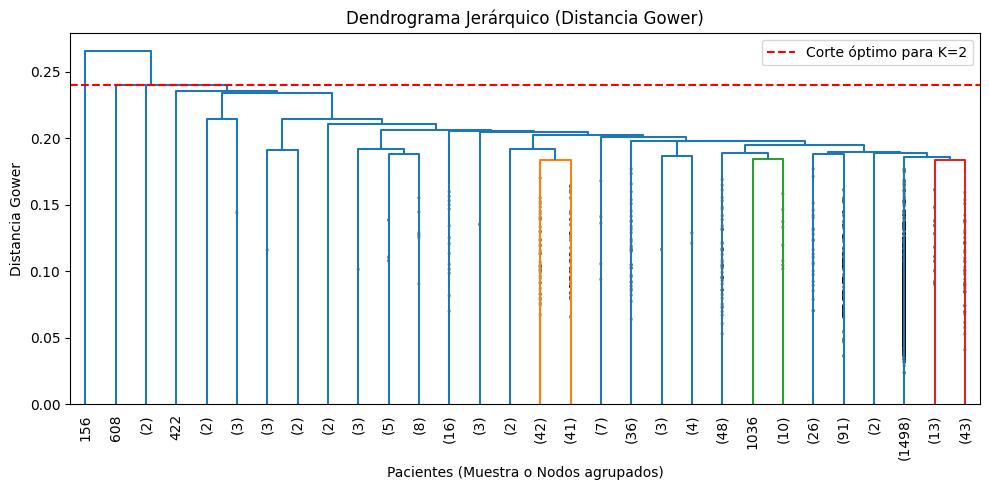

In [41]:
resultados_jer = {}
mejor_k_jer = -1
mejor_score_jer = -1

for k in range(2, 6):
    # linkage='average' es ideal para distancias no euclidianas como Gower
    jerarquico = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_jer = jerarquico.fit_predict(matriz_distancias_gower)

    score_jer = silhouette_score(matriz_distancias_gower, labels_jer, metric='precomputed')
    resultados_jer[k] = score_jer
    print(f"Jerárquico -> Para K={k} | Silhouette Score (Gower): {score_jer:.4f}")

    if score_jer > mejor_score_jer:
        mejor_score_jer = score_jer
        mejor_k_jer = k

print(f"🏆 Mejor K para Jerárquico: {mejor_k_jer} (Score: {mejor_score_jer:.4f})")

# Graficar el Dendrograma
gower_condensada = ssd.squareform(matriz_distancias_gower)
Z = linkage(gower_condensada, method='average')

plt.figure(figsize=(10, 5))
plt.title('Dendrograma Jerárquico (Distancia Gower)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Gower')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_jer > 1: # Prevenir error de índice
    plt.axhline(y=Z[-mejor_k_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_jer}')
plt.legend()
plt.tight_layout()
plt.show()

Clustering jerarquico CON FAMD


2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3216
  -> K=3 | Silhouette: 0.3380
  -> K=4 | Silhouette: 0.3406
  -> K=5 | Silhouette: 0.3363

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2655
  -> K=3 | Silhouette: 0.2602
  -> K=4 | Silhouette: 0.2337
  -> K=5 | Silhouette: 0.1770

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2686
  -> K=3 | Silhouette: 0.1686
  -> K=4 | Silhouette: 0.1482
  -> K=5 | Silhouette: 0.1479

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1536
  -> K=3 | Silhouette: 0.1753
  -> K=4 | Silhouette: 0.1662
  -> K=5 | Silhouette: 0.1552

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.2503
  -> K=3 | Silhouette: 0.1582
  -> K=4 | Silhouette: 0.1467
  -> K=5 | Silhouette: 0.1167

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1662
  -> K=3 | Silhouette: 0.1463
  -> K=4 | Silhouette: 0.1498
  -> K=5 | Silh

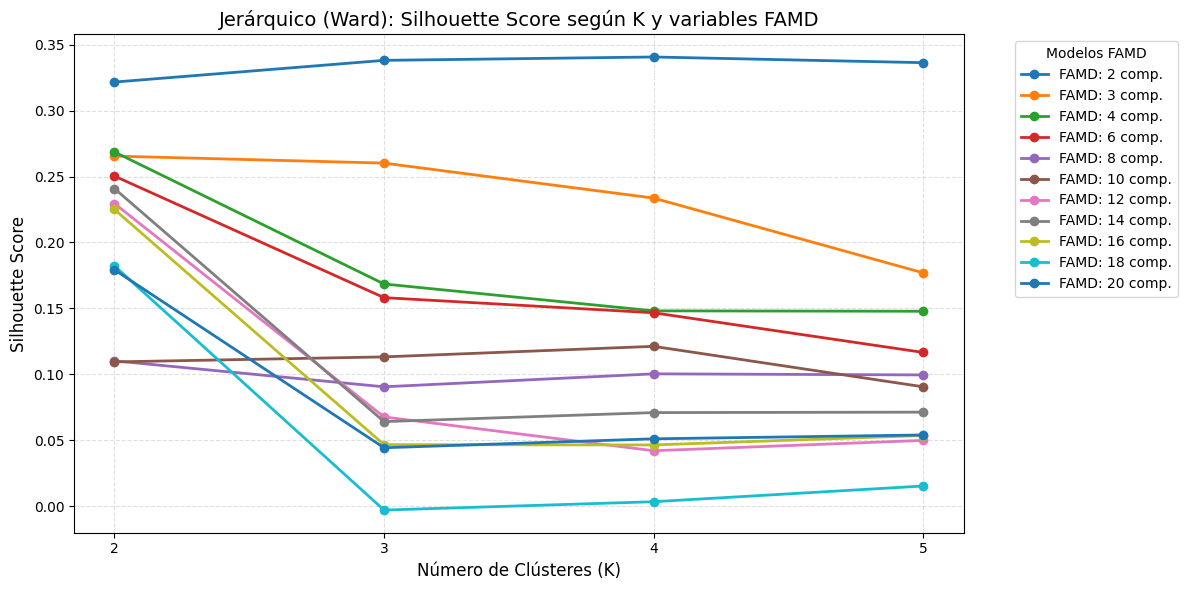


Generando Dendrograma para el modelo óptimo...


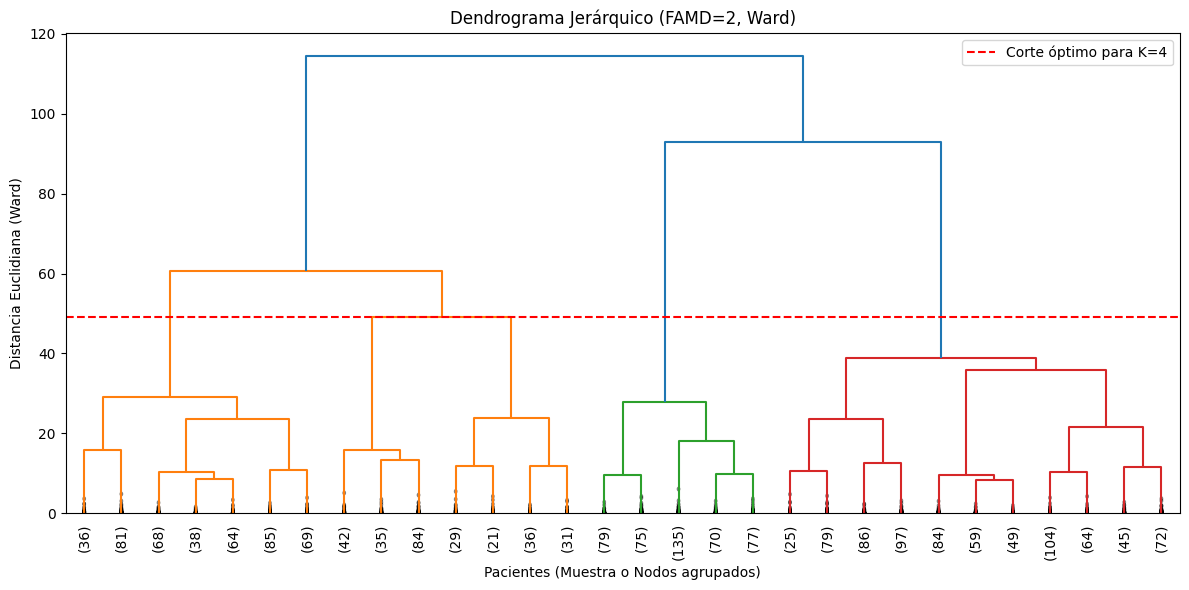

In [42]:
print("\n" + "="*60)
print("2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados (para la gráfica)
resultados_silhouette_jer = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_jer = -1
mejor_k_global_jer = -1
mejor_famd_global_jer = -1

# Variable para guardar las coordenadas FAMD del mejor modelo (para el dendrograma)
mejor_matriz_famd = None

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")

    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()

    scores_sil_k = []

    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Usamos Euclidean y Ward, ideal para el espacio numérico continuo de FAMD
        jer_famd = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels_jer_famd = jer_famd.fit_predict(matriz_famd)

        score_jer_famd = silhouette_score(matriz_famd, labels_jer_famd)
        scores_sil_k.append(score_jer_famd)

        print(f"  -> K={k} | Silhouette: {score_jer_famd:.4f}")

        # Actualizar el campeón absoluto
        if score_jer_famd > mejor_score_global_jer:
            mejor_score_global_jer = score_jer_famd
            mejor_k_global_jer = k
            mejor_famd_global_jer = n_famd
            mejor_matriz_famd = matriz_famd # Guardamos la matriz ganadora para graficar luego

    # Guardar en diccionario para la gráfica
    resultados_silhouette_jer[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO JERÁRQUICO: FAMD = {mejor_famd_global_jer} comp. | K = {mejor_k_global_jer}")
print(f"   (Silhouette Score: {mejor_score_global_jer:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_jer.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3:
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Jerárquico (Ward): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAFICAR EL DENDROGRAMA ÓPTIMO
# ---------------------------------------------------------
print("\nGenerando Dendrograma para el modelo óptimo...")
# Para ward con datos continuos, le pasamos la matriz directamente a linkage
Z_ward = linkage(mejor_matriz_famd, method='ward')

plt.figure(figsize=(12, 6))
plt.title(f'Dendrograma Jerárquico (FAMD={mejor_famd_global_jer}, Ward)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Euclidiana (Ward)')
# truncate_mode para no colapsar la gráfica
dendrogram(Z_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_global_jer > 1:
    # Dibujar la línea de corte horizontal
    plt.axhline(y=Z_ward[-mejor_k_global_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_global_jer}')
plt.legend()
plt.tight_layout()
plt.show()

## GAUSSIAN MIXTURE MODELS

Aplicando FAMD para reducción de dimensionalidad


3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3298 | BIC: 17002
  -> K=3 | Silhouette: 0.3965 | BIC: 16843
  -> K=4 | Silhouette: 0.3613 | BIC: 16853
  -> K=5 | Silhouette: 0.3347 | BIC: 16906

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.3000 | BIC: 24368
  -> K=3 | Silhouette: 0.2920 | BIC: 24245
  -> K=4 | Silhouette: 0.2318 | BIC: 24293
  -> K=5 | Silhouette: 0.2453 | BIC: 24320

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2543 | BIC: 31231
  -> K=3 | Silhouette: 0.2300 | BIC: 31126
  -> K=4 | Silhouette: 0.2062 | BIC: 31122
  -> K=5 | Silhouette: 0.1861 | BIC: 31171

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.2344 | BIC: 38218
  -> K=3 | Silhouette: 0.1954 | BIC: 38009
  -> K=4 | Silhouette: 0.1866 | BIC: 37993
  -> K=5 | Silhouette: 0.1678 | BIC: 38018

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.2432 | BIC: 44484
  -> K=3 | Silho

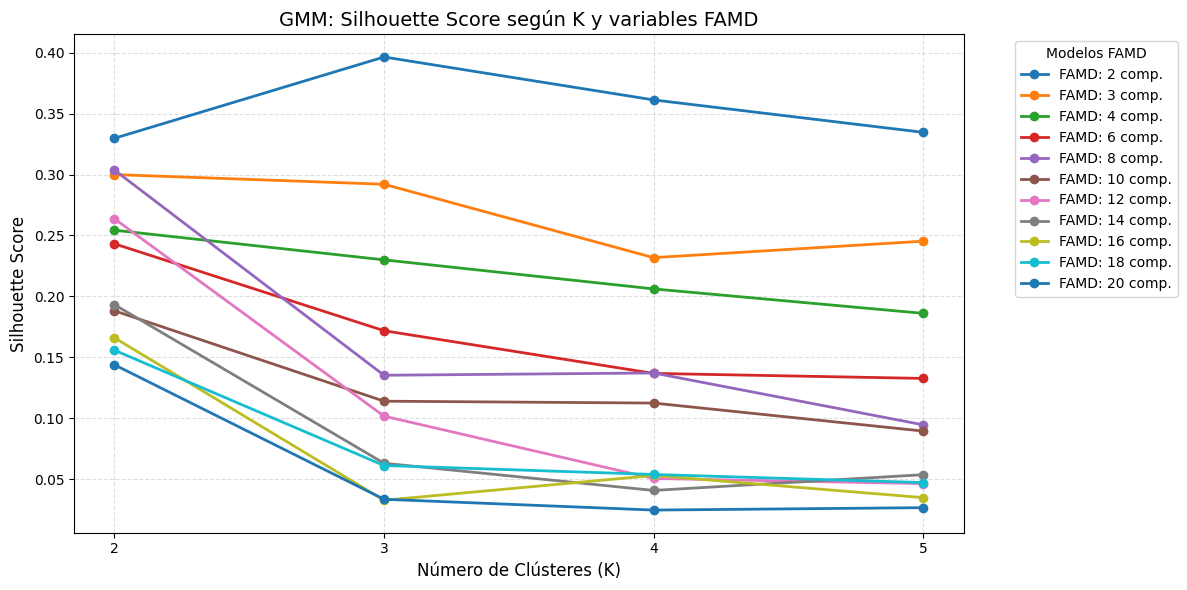

In [43]:
print("\n" + "="*60)
print("3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionarios para guardar los resultados y graficar después
resultados_silhouette_gmm = {}
resultados_bic_gmm = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global = -1
mejor_k_global = -1
mejor_famd_global = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")

    # 1. Reducir dimensionalidad
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()

    scores_sil_k = []
    scores_bic_k = []

    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        labels_gmm = gmm.fit_predict(matriz_famd)

        score_gmm = silhouette_score(matriz_famd, labels_gmm)
        bic_score = gmm.bic(matriz_famd)

        scores_sil_k.append(score_gmm)
        scores_bic_k.append(bic_score)

        print(f"  -> K={k} | Silhouette: {score_gmm:.4f} | BIC: {bic_score:.0f}")

        # Actualizar el campeón absoluto
        if score_gmm > mejor_score_global:
            mejor_score_global = score_gmm
            mejor_k_global = k
            mejor_famd_global = n_famd

    # Guardar en diccionarios
    resultados_silhouette_gmm[n_famd] = scores_sil_k
    resultados_bic_gmm[n_famd] = scores_bic_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO GMM: FAMD = {mejor_famd_global} comp. | K = {mejor_k_global}")
print(f"   (Silhouette Score: {mejor_score_global:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_gmm.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3:
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('GMM: Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

In [44]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


## Busqueda de las variables más relevantes

En vista de que ninguno de los resultados es suficientemente bueno, se va a ejecutar una prueba de importancia de variables aplicando k-means a todas las posibles combinaciones de variables.

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np

from itertools import combinations
import heapq

In [2]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [19]:
trainset_no_ohe.head(10)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,1,0,0,0,0,1,3.0,1,b'M',7.0
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,1,0,0,0,0,1,3.0,1,b'M',3.0
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,1,0,0,0,0,0,3.0,1,b'M',3.0


In [ ]:


print(trainset_no_ohe.shape)

(1919, 62)


In [4]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas] = trainset_no_ohe[var_numericas].astype('float64')
trainset_no_ohe[var_categoricas] = trainset_no_ohe[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [5]:

var_num = trainset_no_ohe.select_dtypes(include=['number'])
var_num.shape

(1919, 46)

In [6]:
var_num.head(10)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,plaquetas_totales,volumen_plaquetario_medio,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,-0.148788,-0.064880,-0.253993,0.564297,0.931707,-0.485349,-0.286241,0.286165,0.271704,-0.024538
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.324984,-1.395746,2.736229,-0.674377,-1.007353,-0.429424,0.395955,-0.564023,-0.514788,-1.792289
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,-1.146655,0.933270,-0.483653,0.004270,-0.024542,-0.429424,-0.184990,-0.322245,0.244583,1.214156
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,-0.440472,0.489648,-0.191021,1.921592,-0.024542,0.031964,-0.321788,0.646851,0.217463,-0.419084
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,-0.302306,-1.395746,0.854491,-1.470505,0.666082,1.360202,4.937467,7.921013,3.010867,0.591839
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,-0.102733,1.376892,-0.766099,-1.323370,1.675456,31.825777,-0.030417,-0.529342,0.841233,1.550274
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,-0.271603,0.156931,-0.504953,-0.762202,0.453583,0.059927,0.339039,-0.272700,-0.460548,0.545130
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,0.588098,-0.619407,0.239568,0.291392,-0.432187,-0.051925,-0.380502,-0.524387,0.244583,-0.538828
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,-0.087381,-0.952124,2.203749,-0.142865,-1.060478,-0.163776,-0.401870,-0.277654,-0.487668,-1.213793
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,-0.732157,-0.064880,-0.744800,-1.027958,-0.316729,0.213723,-0.490739,0.805394,1.085316,-1.505930


Para la busqueda de las variables más relevantes, el metodo de fuerza bruta, probando todas las posibles combinaciones de variables es computacionalmente inviable que que se deberian probar combinaciones del orden de los 10 billones.

por tanto utilizamos el método de forward selecion que funciona construyendo la combinación ideal paso a paso en lugar de probar todo a ciegas:

1. Prueba las 46 variables de una en una y encuentra la que da el mejor clúster. (46 pruebas).

2. Fija esa variable ganadora y prueba a añadirle una segunda variable de entre las 45 restantes. (45 pruebas).

3. Encuentra la mejor pareja. La fija, y busca la mejor tercera variable añadiendo una de las 44 restantes. (44 pruebas).

In [52]:
print("=" * 80)
print("FORWARD SELECTION")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")

    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []

    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()

    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)

        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo

    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)

    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")

    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]

    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None

        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]

            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)

            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata

        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)

        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable.
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]

    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]

    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }

    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('rigidez_iqr', 'ratio_iqr_mediana') (Score: 0.9764)
  -> + Variable 3: 'ratio_albumina_creatinina' | Nuevo Score: 0.9689
  -> + Variable 4: 'albumina_orina_mg_l' | Nuevo Score: 0.9642
  -> + Variable 5: 'tiempo_seg_cond3' | Nuevo Score: 0.9572
  -> + Variable 6: 'plomo_sangre_umol_l' | Nuevo Score: 0.9478
  -> + Variable 7: 'tiempo_seg_cond2' | Nuevo Score: 0.9387
  -> + Variable 8: 'rigidez_mediana_kpa' | Nuevo Score: 0.9299
  -> + Variable 9: 'medidas_validas_elasto' | Nuevo Score: 0.9197
  -> + Variable 10: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.9071
  -> + Variable 11: 'cadmio_sangre_nmol_l' | Nuevo Score: 0.8979
  -> + Variable 12: 'linfocitos_abs' | Nuevo Score: 0.7731
  -> + Variable 13: 'trigliceridos_mmol_l' | Nuevo Score: 0.7093
  -> + Variable 14: 'leucocitos_totales' | Nuevo Score: 0.7228
  -> + Variable 15: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.7267
  -> + Variable 16: 'eosinofilos

Al observar las variables más relevantes vemos que algunas no tienen demasiado sentido clinico por ejemplo la variable psu (Unidad Primaria de Muestreo), que es un pseudo-estrato utilizado para enmascarar la varianza muestral por motivos de privacidad. No tiene absolutamente ningún valor clínico o biológico, por lo que cualquier clúster basado en ella será un artefacto estadístico.

Tambiénj aunque se hizo un estudio preveio de correlación estaba más enfocado en eliminar variables redundantes como mediciones representadas en distintas unidades.

Denido a que en K-Means, si metes dos variables muy correlacionadas, es como darle "dos votos" a una misma característica biológica, sesgando el clúster hacia esa dirección. Se va a realizar un estudio de correlaciones y simplificar aquellas con más de 0.8 de correlación.

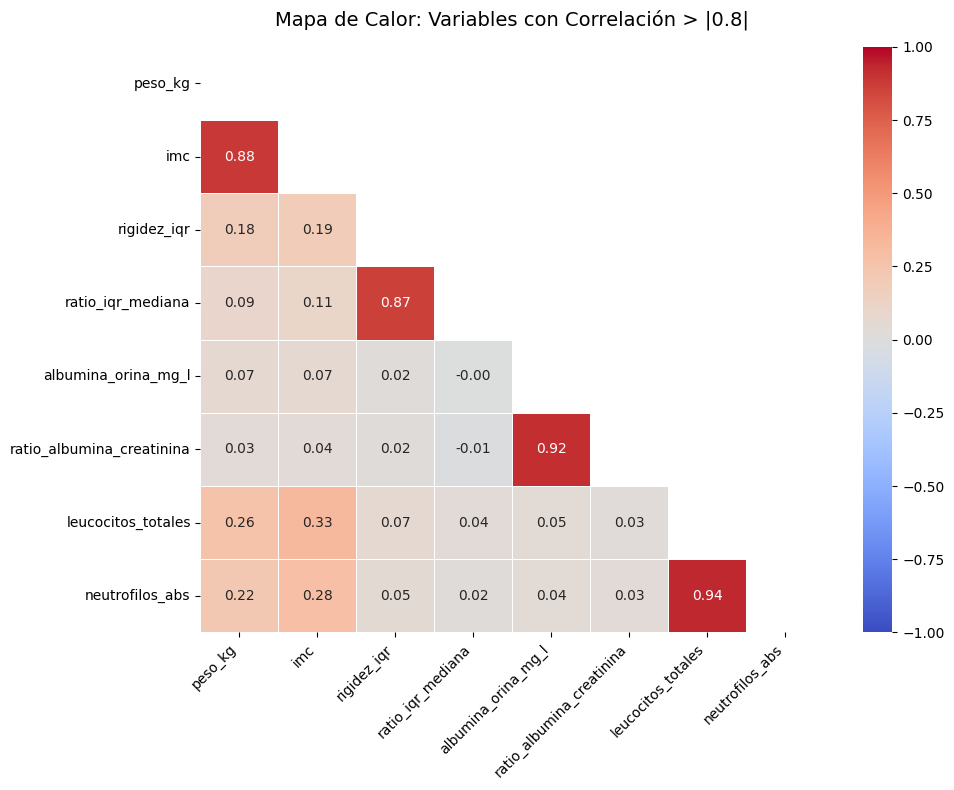

In [7]:
corr_matrix = var_num.corr()

high_corr_mask = (corr_matrix.abs() > 0.8) & (corr_matrix != 1.0)

# 3. Identificar qué columnas tienen al menos una correlación alta
cols_to_keep = high_corr_mask.any()
high_corr_vars = cols_to_keep[cols_to_keep].index

# 4. Filtrar la matriz de correlación para mostrar solo estas variables problemáticas
filtered_corr_matrix = corr_matrix.loc[high_corr_vars, high_corr_vars]

# 5. Configurar y dibujar el mapa de calor
plt.figure(figsize=(10, 8)) # Ajusta el tamaño si es necesario
sns.heatmap(filtered_corr_matrix,
            annot=True,            # Muestra el valor numérico en cada celda
            cmap='coolwarm',       # Paleta divergente: rojo (positivo), azul (negativo)
            vmin=-1, vmax=1,       # Fija los límites de la escala de color
            center=0,              # Centra el color neutro en el 0
            fmt=".2f",             # Muestra solo 2 decimales
            linewidths=0.5,        # Líneas de separación entre celdas
            mask=np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))) # Opcional: oculta el triángulo superior para no duplicar info

plt.title('Mapa de Calor: Variables con Correlación > |0.8|', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
columnas_a_eliminar = ['peso_kg', 'albumina_orina_mg_l', 'neutrofilos_abs']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 43)

Se van a eliminar también variables de control de calidad de las pruebas médicas como son:

1. rigidez_iqr y ratio_iqr_mediana: Son medidas de la desviación/control de calidad de los disparos del FibroScan, no la enfermedad del hígado en sí
2. medidas_validas_elasto e intentos_totales_elasto no son variables biológicas, es el conteo de cuántas veces el técnico disparó el escaner.

In [9]:
columnas_a_eliminar = ['rigidez_iqr', 'ratio_iqr_mediana','medidas_validas_elasto','intentos_totales_elasto']
# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 39)

Para las varaiables 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4':

Se observa una falta de varianza. estas son variables que miden el equilibrio de diferentes formas. La inmensa mayoría de las personas adultas que pueden caminar pasan las condiciones 1 y 2. Esto significa que en tu dataset, esas dos columnas estarán llenas con el mismo valor lo que resulta en una variable sin varianza que no aporta ninguna información para separar grupos.

In [10]:
condiciones = ['tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4']

print("--- DIAGNÓSTICO DE VARIANZA Y EFECTO TECHO ---\n")

for col in condiciones:
    if col in var_num.columns:
        # Calcular varianza
        varianza = var_num[col].var()

        # Encontrar el valor máximo (el "techo" de la prueba)
        max_val = var_num[col].max()

        # Contar cuántos pacientes lograron ese valor máximo
        num_max_vals = (var_num[col] == max_val).sum()
        pct_max_vals = (num_max_vals / len(var_num)) * 100

        print(f"Variable: {col}")
        print(f"  Varianza: {varianza:.4f}")
        print(f"  Valor Máximo ('Techo'): {max_val} segundos")
        print(f"  Pacientes en el techo: {num_max_vals} ({pct_max_vals:.1f}% del total)\n")
    else:
        print(f"La columna {col} no se encuentra en el DataFrame.\n")

--- DIAGNÓSTICO DE VARIANZA Y EFECTO TECHO ---

Variable: tiempo_seg_cond1
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.1440674418393514 segundos
  Pacientes en el techo: 1652 (86.1% del total)

Variable: tiempo_seg_cond2
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.2451034271325411 segundos
  Pacientes en el techo: 1632 (85.0% del total)

Variable: tiempo_seg_cond3
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.1621364881979306 segundos
  Pacientes en el techo: 1615 (84.2% del total)

Variable: tiempo_seg_cond4
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.8100591789827326 segundos
  Pacientes en el techo: 1006 (52.4% del total)



In [11]:
columnas_a_eliminar = ['tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 36)

se elimina la variable estadistica de psu varianza

Se eliminana las variables de mercurio y cadmio debido a su poco sentido clinico para el estudio de la hipertensión y evitar que aporten ruido.

In [12]:
columnas_a_eliminar = ['psu', 'cadmio_sangre_nmol_l', 'mercurio_sangre_nmol_l']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 33)

In [13]:
print("=" * 80)
print("FORWARD SELECTION k-MEANS")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")

    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []

    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()

    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)

        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo

    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)

    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")

    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]

    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None

        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]

            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)

            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata

        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)

        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable.
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]

    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]

    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }

    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION k-MEANS

[ Iniciando búsqueda para K=2 ]


KeyboardInterrupt: 

In [60]:
print("=" * 80)
print("FORWARD SELECTION CON TAMAÑO DE CLÚSTERES (N) PARA K-MEANS")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []
campeon_global_conteos = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")

    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []

    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    mejor_labels_par = None

    # Probamos las parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)

        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            mejor_labels_par = labels # Guardamos las etiquetas ganadoras

    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)

    # Calculamos N por clúster
    conteos_par = np.bincount(mejor_labels_par).tolist()

    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f}) | Tamaños N: {conteos_par}")

    # Guardamos el historial de scores y conteos
    historial_scores = [mejor_score_par]
    historial_conteos = [conteos_par]

    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        mejor_labels_paso = None

        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]

            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)

            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                mejor_labels_paso = labels # Guardamos las etiquetas ganadoras

        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)

        # Calculamos N por clúster
        conteos_paso = np.bincount(mejor_labels_paso).tolist()

        historial_scores.append(mejor_score_paso)
        historial_conteos.append(conteos_paso)

        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f} | Tamaños N: {conteos_paso}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    conteos_pico = historial_conteos[indice_mejor_momento]

    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]

    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico,
        'conteos': conteos_pico
    }

    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico
        campeon_global_conteos = conteos_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Distribución de Pacientes (N): {campeon_global_conteos}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> Distribución de Pacientes (N): {res['conteos']}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION CON TAMAÑO DE CLÚSTERES (N) PARA K-MEANS

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('ratio_albumina_creatinina', 'plomo_sangre_umol_l') (Score: 0.9375) | Tamaños N: [1905, 14]
  -> + Variable 3: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.9073 | Tamaños N: [1902, 17]
  -> + Variable 4: 'rigidez_mediana_kpa' | Nuevo Score: 0.8678 | Tamaños N: [1899, 20]
  -> + Variable 5: 'trigliceridos_mmol_l' | Nuevo Score: 0.8345 | Tamaños N: [1899, 20]
  -> + Variable 6: 'peso_flebotomia' | Nuevo Score: 0.7926 | Tamaños N: [1899, 20]
  -> + Variable 7: 'pulso' | Nuevo Score: 0.7781 | Tamaños N: [1902, 17]
  -> + Variable 8: 'leucocitos_totales' | Nuevo Score: 0.6956 | Tamaños N: [1890, 29]
  -> + Variable 9: 'hemoglobina_g_dl' | Nuevo Score: 0.7306 | Tamaños N: [1902, 17]
  -> + Variable 10: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.6504 | Tamaños N: [1890, 29]
  -> + Variable 11: 'eritrocitos_totales' | Nuevo Score: 0.6664 | Tamaños N: [1900, 19]
  -> + Vari

Clustering Jerarquico

In [61]:
import numpy as np
from itertools import combinations
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("=" * 80)
print("FORWARD SELECTION: CLUSTERING JERÁRQUICO CON TAMAÑO (N)")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []
campeon_global_conteos = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")

    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []

    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    mejor_labels_par = None

    # Probamos las parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]

        # INSTANCIAMOS EL CLUSTERING JERÁRQUICO
        jerarquico = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = jerarquico.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)

        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            mejor_labels_par = labels # Guardamos las etiquetas ganadoras

    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)

    # Calculamos N por clúster
    conteos_par = np.bincount(mejor_labels_par).tolist()

    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f}) | Tamaños N: {conteos_par}")

    # Guardamos el historial de scores y conteos
    historial_scores = [mejor_score_par]
    historial_conteos = [conteos_par]

    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        mejor_labels_paso = None

        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]

            # INSTANCIAMOS EL CLUSTERING JERÁRQUICO
            jerarquico = AgglomerativeClustering(n_clusters=k, linkage='ward')
            labels = jerarquico.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)

            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                mejor_labels_paso = labels # Guardamos las etiquetas ganadoras

        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)

        # Calculamos N por clúster
        conteos_paso = np.bincount(mejor_labels_paso).tolist()

        historial_scores.append(mejor_score_paso)
        historial_conteos.append(conteos_paso)

        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f} | Tamaños N: {conteos_paso}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    conteos_pico = historial_conteos[indice_mejor_momento]

    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]

    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico,
        'conteos': conteos_pico
    }

    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico
        campeon_global_conteos = conteos_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Distribución de Pacientes (N): {campeon_global_conteos}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> Distribución de Pacientes (N): {res['conteos']}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION: CLUSTERING JERÁRQUICO CON TAMAÑO (N)

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('trigliceridos_mmol_l', 'plomo_sangre_umol_l') (Score: 0.9653) | Tamaños N: [1918, 1]
  -> + Variable 3: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.9495 | Tamaños N: [1918, 1]
  -> + Variable 4: 'eosinofilos_abs' | Nuevo Score: 0.9366 | Tamaños N: [1918, 1]
  -> + Variable 5: 'rigidez_mediana_kpa' | Nuevo Score: 0.9284 | Tamaños N: [1918, 1]
  -> + Variable 6: 'ratio_albumina_creatinina' | Nuevo Score: 0.8141 | Tamaños N: [1905, 14]
  -> + Variable 7: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.7957 | Tamaños N: [1905, 14]
  -> + Variable 8: 'monocitos_abs' | Nuevo Score: 0.7833 | Tamaños N: [1907, 12]
  -> + Variable 9: 'cap_iqr' | Nuevo Score: 0.7604 | Tamaños N: [1907, 12]
  -> + Variable 10: 'plaquetas_totales' | Nuevo Score: 0.7403 | Tamaños N: [1907, 12]
  -> + Variable 11: 'eritrocitos_totales' | Nuevo Score: 0.7148 | Tamaños N: [1906, 13]
  -> + Variable 12: 

Clustering GMM

In [15]:
import numpy as np
from itertools import combinations
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

print("=" * 80)
print("FORWARD SELECTION: GAUSSIAN MIXTURE MODEL (GMM) CON TAMAÑO (N)")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []
campeon_global_conteos = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")

    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []

    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    mejor_labels_par = None

    # Probamos las parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]

        # INSTANCIAMOS EL GAUSSIAN MIXTURE MODEL
        # n_components es el equivalente a los clústeres en GMM
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels = gmm.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)

        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            mejor_labels_par = labels # Guardamos las etiquetas ganadoras

    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)

    # Calculamos N por clúster
    conteos_par = np.bincount(mejor_labels_par).tolist()

    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f}) | Tamaños N: {conteos_par}")

    # Guardamos el historial de scores y conteos
    historial_scores = [mejor_score_par]
    historial_conteos = [conteos_par]

    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        mejor_labels_paso = None

        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]

            # INSTANCIAMOS EL GAUSSIAN MIXTURE MODEL
            gmm = GaussianMixture(n_components=k, random_state=42)
            labels = gmm.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)

            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                mejor_labels_paso = labels # Guardamos las etiquetas ganadoras

        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)

        # Calculamos N por clúster
        conteos_paso = np.bincount(mejor_labels_paso).tolist()

        historial_scores.append(mejor_score_paso)
        historial_conteos.append(conteos_paso)

        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f} | Tamaños N: {conteos_paso}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    conteos_pico = historial_conteos[indice_mejor_momento]

    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]

    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico,
        'conteos': conteos_pico
    }

    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico
        campeon_global_conteos = conteos_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Distribución de Pacientes (N): {campeon_global_conteos}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> Distribución de Pacientes (N): {res['conteos']}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION: GAUSSIAN MIXTURE MODEL (GMM) CON TAMAÑO (N)

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('rigidez_mediana_kpa', 'proteina_c_reactiva_mg_l') (Score: 0.6666) | Tamaños N: [267, 1652]
  -> + Variable 3: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.5776 | Tamaños N: [301, 1618]
  -> + Variable 4: 'plomo_sangre_umol_l' | Nuevo Score: 0.5390 | Tamaños N: [1682, 237]
  -> + Variable 5: 'eosinofilos_abs' | Nuevo Score: 0.5200 | Tamaños N: [1618, 301]
  -> + Variable 6: 'volumen_corpuscular_medio' | Nuevo Score: 0.4773 | Tamaños N: [301, 1618]
  -> + Variable 7: 'ratio_albumina_creatinina' | Nuevo Score: 0.4414 | Tamaños N: [326, 1593]
  -> + Variable 8: 'trigliceridos_mmol_l' | Nuevo Score: 0.4364 | Tamaños N: [1595, 324]
  -> + Variable 9: 'monocitos_abs' | Nuevo Score: 0.4052 | Tamaños N: [1597, 322]
  -> + Variable 10: 'selenio_sangre_umol_l' | Nuevo Score: 0.3758 | Tamaños N: [324, 1595]
  -> + Variable 11: 'hemoglobina_g_dl' | Nuevo Score: 0.3524 | Tam

Adicionalmente a los resultados anteriores se van a probar los siguientes grupos de variables debido a su sentido clínico:

1. ratio_albumina_creatinina, PCR, triglicéridos, IMC (fenotipo: renal–inflamatorio–metabólico).
2. ratio_albumina_creatinina, plomo, PCR, rigidez hepática (rigidez_mediana_kpa), triglicéridos, IMC (fenotipo: daño renal precoz + exposición ambiental + inflamación + metabolismo).


--- EVALUANDO K-MEANS ---
Para K = 2 -> Silhouette Score: 0.4629
Para K = 3 -> Silhouette Score: 0.4359
Para K = 4 -> Silhouette Score: 0.4085
Para K = 5 -> Silhouette Score: 0.4304
Para K = 6 -> Silhouette Score: 0.4339

🌟 El número óptimo de clústeres según Silhouette es: K = 2 (Score: 0.4629)


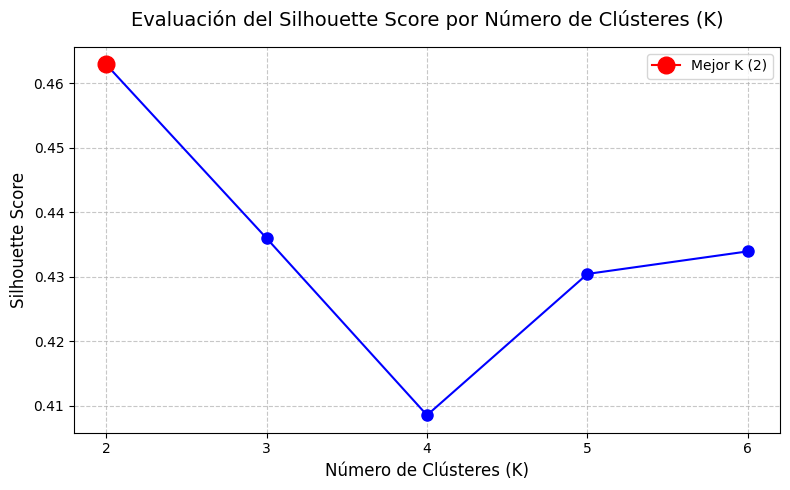

In [63]:
columnas_modelo = [
    'ratio_albumina_creatinina',
    'proteina_c_reactiva_mg_l',
    'trigliceridos_mmol_l',
    'imc'
]

X = var_num[columnas_modelo].copy()

valores_k = [2, 3, 4, 5, 6]
scores_silhouette = []

print("\n--- EVALUANDO K-MEANS ---")
for k in valores_k:
    # Configuramos el modelo KMeans
    # random_state=42 asegura que los resultados sean reproducibles
    # n_init=10 es una buena práctica para evitar mínimos locales
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Entrenamos el modelo y predecimos a qué clúster pertenece cada paciente
    etiquetas_clusters = modelo_kmeans.fit_predict(X)

    # Calculamos el Silhouette Score
    score = silhouette_score(X, etiquetas_clusters)
    scores_silhouette.append(score)

    print(f"Para K = {k} -> Silhouette Score: {score:.4f}")

# 4. Encontrar el mejor K automáticamente
mejor_k = valores_k[scores_silhouette.index(max(scores_silhouette))]
print(f"\n🌟 El número óptimo de clústeres según Silhouette es: K = {mejor_k} (Score: {max(scores_silhouette):.4f})")

# 5. Visualizar los resultados en una gráfica
plt.figure(figsize=(8, 5))
plt.plot(valores_k, scores_silhouette, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Evaluación del Silhouette Score por Número de Clústeres (K)', fontsize=14, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar el punto máximo
plt.plot(mejor_k, max(scores_silhouette), marker='o', color='red', markersize=12, label=f'Mejor K ({mejor_k})')
plt.legend()

plt.tight_layout()
plt.show()


--- EVALUANDO K-MEANS ---
Para K = 2 -> Silhouette Score: 0.4313
Para K = 3 -> Silhouette Score: 0.4036
Para K = 4 -> Silhouette Score: 0.3718
Para K = 5 -> Silhouette Score: 0.3750
Para K = 6 -> Silhouette Score: 0.3652

🌟 El número óptimo de clústeres según Silhouette es: K = 2 (Score: 0.4313)


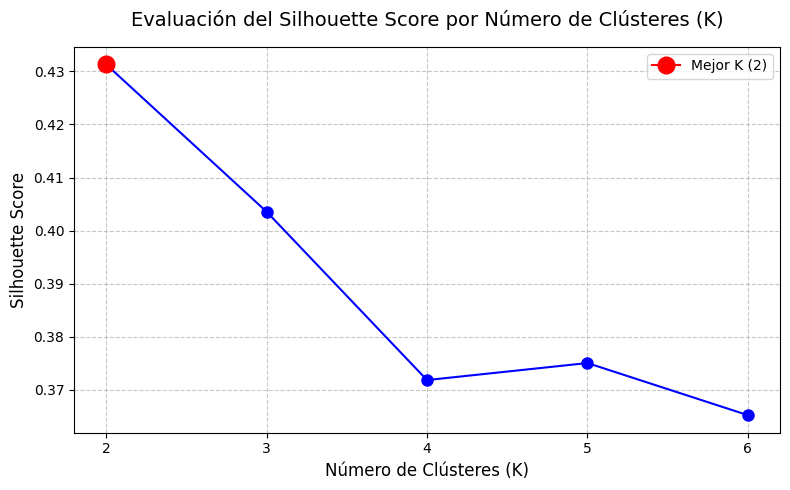

In [64]:
columnas_modelo = [
    'ratio_albumina_creatinina',
    'plomo_sangre_umol_l',
    'proteina_c_reactiva_mg_l',
    'rigidez_mediana_kpa',
    'trigliceridos_mmol_l',
    'imc'
]

X = var_num[columnas_modelo].copy()

valores_k = [2, 3, 4, 5, 6]
scores_silhouette = []

print("\n--- EVALUANDO K-MEANS ---")
for k in valores_k:
    # Configuramos el modelo KMeans
    # random_state=42 asegura que los resultados sean reproducibles
    # n_init=10 es una buena práctica para evitar mínimos locales
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Entrenamos el modelo y predecimos a qué clúster pertenece cada paciente
    etiquetas_clusters = modelo_kmeans.fit_predict(X)

    # Calculamos el Silhouette Score
    score = silhouette_score(X, etiquetas_clusters)
    scores_silhouette.append(score)

    print(f"Para K = {k} -> Silhouette Score: {score:.4f}")

# 4. Encontrar el mejor K automáticamente
mejor_k = valores_k[scores_silhouette.index(max(scores_silhouette))]
print(f"\n🌟 El número óptimo de clústeres según Silhouette es: K = {mejor_k} (Score: {max(scores_silhouette):.4f})")

# 5. Visualizar los resultados en una gráfica
plt.figure(figsize=(8, 5))
plt.plot(valores_k, scores_silhouette, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Evaluación del Silhouette Score por Número de Clústeres (K)', fontsize=14, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar el punto máximo
plt.plot(mejor_k, max(scores_silhouette), marker='o', color='red', markersize=12, label=f'Mejor K ({mejor_k})')
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


-----------------------------------------------------
-----------------------------------------------------